Device: cuda
Node feature dim: 15 | Edge feature dim: 3 | Classes: 7
Train: 1945 | Val: 417 | Test: 417


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 001 | Train Loss: 1.8546 | Val Loss: 1.5855 | Train Acc: 0.3080 | Val Acc: 0.4508 | LR: 0.000200
Epoch 005 | Train Loss: 0.7041 | Val Loss: 0.6608 | Train Acc: 0.7928 | Val Acc: 0.8441 | LR: 0.000997
Epoch 010 | Train Loss: 0.4947 | Val Loss: 0.4831 | Train Acc: 0.8694 | Val Acc: 0.8921 | LR: 0.000968
Epoch 015 | Train Loss: 0.4135 | Val Loss: 0.4799 | Train Acc: 0.9054 | Val Acc: 0.8801 | LR: 0.000921
Epoch 020 | Train Loss: 0.3507 | Val Loss: 0.4554 | Train Acc: 0.9306 | Val Acc: 0.8873 | LR: 0.000859
Epoch 025 | Train Loss: 0.3289 | Val Loss: 0.3746 | Train Acc: 0.9440 | Val Acc: 0.9305 | LR: 0.000783
Epoch 030 | Train Loss: 0.2822 | Val Loss: 0.3650 | Train Acc: 0.9578 | Val Acc: 0.9209 | LR: 0.000696
Epoch 035 | Train Loss: 0.2490 | Val Loss: 0.3443 | Train Acc: 0.9763 | Val Acc: 0.9209 | LR: 0.000602
Epoch 040 | Train Loss: 0.2399 | Val Loss: 0.3325 | Train Acc: 0.9748 | Val Acc: 0.9281 | LR: 0.000504
Epoch 045 | Train Loss: 0.2204 | Val Loss: 0.3432 | Train Acc: 0.9835 | V

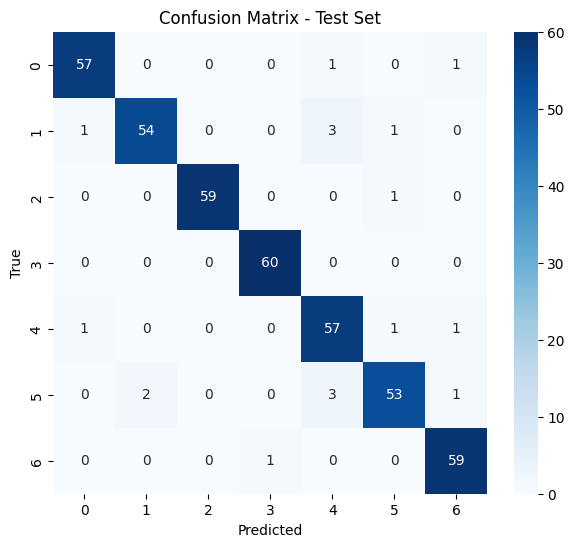

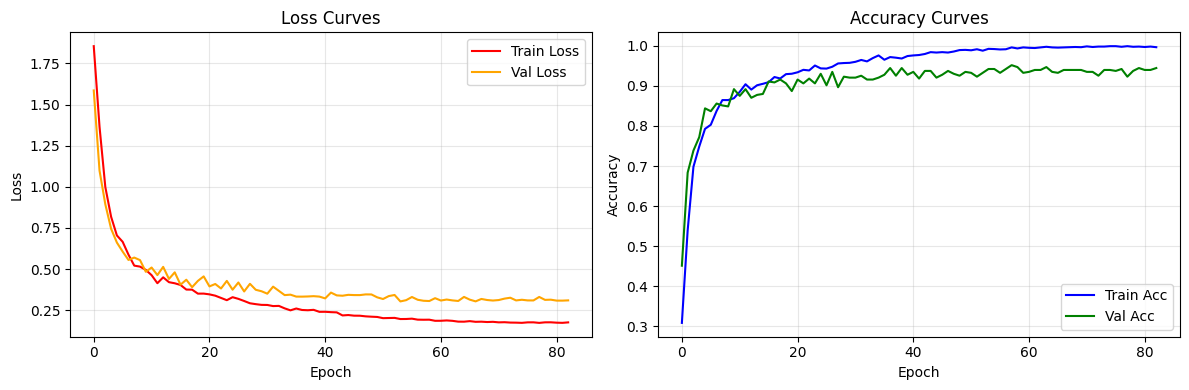


🏁 Training complete
Best Validation Accuracy: 0.9520
Final Test Accuracy: 0.9568
Train graphs: 1945 | Val: 417 | Test: 417


In [ ]:
# ==========================================================
# V7.2.0 - GraphSAGE + EdgeMLP (2 layers, concat fusion) + RWR diffusion
# - Ajout Random Walk with Restart (diffusion après 2e conv)
# - Gate apprenable pour mixer x et x_rwr
# - Reste identique à V7.1.1 (normalisation train-only, DropEdge, LS, etc.)
# ==========================================================

import torch
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing, global_mean_pool, global_max_pool, BatchNorm
from torch_geometric.loader import DataLoader
from torch_geometric.utils import dropout_edge, add_self_loops, to_undirected, degree
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Config
# -----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

BATCH_SIZE = 24
HIDDEN = 96
DROPOUT_P = 0.3
WEIGHT_DECAY = 1e-3
BASE_LR = 1e-3
MAX_EPOCHS = 120
PATIENCE_ES = 25
USE_DROPEDGE = True
DROPEDGE_P = 0.10
GRAD_CLIP_NORM = 1.0
WARMUP_EPOCHS = 5
COSINE_TMAX = 80
LABEL_SMOOTH_EPS = 0.02
SAVE_PATH = "/content/drive/MyDrive/best_graphsage_v7_2_0_RWR.pt"

# RWR hyperparams
RWR_ALPHA = 0.15   # proba de "restart" vers h0
RWR_STEPS = 10     # itérations de diffusion

# -----------------------------
# Label smoothing loss
# -----------------------------
class LabelSmoothingCrossEntropy(torch.nn.Module):
    def __init__(self, eps):
        super().__init__()
        self.eps = eps
        self.log_softmax = torch.nn.LogSoftmax(dim=-1)
    def forward(self, preds, targets):
        n_classes = preds.size(-1)
        log_preds = self.log_softmax(preds)
        with torch.no_grad():
            true_dist = torch.zeros_like(log_preds)
            true_dist.fill_(self.eps / (n_classes - 1))
            true_dist.scatter_(1, targets.data.unsqueeze(1), 1 - self.eps)
        return torch.mean(torch.sum(-true_dist * log_preds, dim=-1))

# -----------------------------
# EdgeSAGEConv (v2.1 - BN + Dropout)
# -----------------------------
class EdgeSAGEConv(MessagePassing):
    def __init__(self, in_channels, out_channels, edge_dim, dropout_p=0.3):
        super().__init__(aggr='mean')
        self.lin_node = torch.nn.Linear(in_channels, out_channels, bias=False)

        self.edge_mlp = torch.nn.Sequential(
            torch.nn.Linear(out_channels + edge_dim, out_channels),
            torch.nn.ReLU(),
            torch.nn.BatchNorm1d(out_channels),
            torch.nn.Dropout(p=dropout_p),
            torch.nn.Linear(out_channels, out_channels)
        )

        self.update_lin = torch.nn.Linear(out_channels, out_channels)

    def forward(self, x, edge_index, edge_attr):
        h = self.lin_node(x)
        out = self.propagate(edge_index, x=h, edge_attr=edge_attr)
        return self.update_lin(F.leaky_relu(h + out, negative_slope=0.1))

    def message(self, x_j, edge_attr):
        m = torch.cat([x_j, edge_attr], dim=-1)
        return self.edge_mlp(m)

# -----------------------------
# Random Walk with Restart (RWR) diffusion
# -----------------------------
class RandomWalkWithRestart(torch.nn.Module):
    """
    Diffusion: h_{t+1} = (1 - alpha) * P * h_t + alpha * h0
    P = D^{-1} A (row-stochastic). Fonctionne en batch car PyG concatène
    les graphes en blocs disjoints.
    """
    def __init__(self, alpha=0.15, steps=10, add_loops=True, symmetric_undirected=True):
        super().__init__()
        self.alpha = alpha
        self.steps = steps
        self.add_loops = add_loops
        self.symmetric_undirected = symmetric_undirected

    def forward(self, x, edge_index):
        N = x.size(0)
        device = x.device

        ei = edge_index
        if self.symmetric_undirected:
            ei = to_undirected(ei, num_nodes=N)
        if self.add_loops:
            ei, _ = add_self_loops(ei, num_nodes=N)

        # P = D^{-1} A (row-stochastic)
        row, col = ei[0], ei[1]
        deg = degree(row, N, dtype=x.dtype).clamp(min=1)
        vals = 1.0 / deg[row]

        P = torch.sparse_coo_tensor(
            torch.stack([row, col]),
            vals.to(device),
            size=(N, N),
            device=device
        ).coalesce()

        h0 = x
        h = x
        one_minus_alpha = 1.0 - self.alpha
        for _ in range(self.steps):
            h = one_minus_alpha * torch.sparse.mm(P, h) + self.alpha * h0
        return h

# -----------------------------
# GraphSAGE model (2 layers) + RWR diffusion
# -----------------------------
class GraphSAGE_EdgeMLP2L(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, edge_dim, dropout_p=0.4,
                 rwr_alpha=0.15, rwr_steps=10):
        super().__init__()
        self.conv1 = EdgeSAGEConv(in_channels, hidden_channels, edge_dim)
        self.bn1 = BatchNorm(hidden_channels)
        self.conv2 = EdgeSAGEConv(hidden_channels, hidden_channels, edge_dim)
        self.bn2 = BatchNorm(hidden_channels)

        # Diffusion RWR + gate apprenable
        self.rwr = RandomWalkWithRestart(alpha=rwr_alpha, steps=rwr_steps)
        self.rwr_gamma = torch.nn.Parameter(torch.tensor(0.0))  # sigmoid(0)=0.5

        self.lin = torch.nn.Linear(hidden_channels * 2, num_classes)
        self.dropout = torch.nn.Dropout(dropout_p)
        self.act = lambda x: F.leaky_relu(x, 0.1)

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.act(self.bn1(self.conv1(x, edge_index, edge_attr)))
        x = self.dropout(x)
        x = self.act(self.bn2(self.conv2(x, edge_index, edge_attr)))
        x = self.dropout(x)

        # RWR diffusion + fusion résiduelle (gate)
        x_rwr = self.rwr(x, edge_index)
        g = torch.sigmoid(self.rwr_gamma)
        x = (1 - g) * x + g * x_rwr

        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        return self.lin(torch.cat([x_mean, x_max], dim=1))

# -----------------------------
# Data preparation
# -----------------------------

assert 'graph_list' in globals(), "⚠️ Le dataset 'graph_list' doit être chargé avant ce script."

edge_dim = graph_list[0].edge_attr.shape[1]
in_channels = graph_list[0].x.shape[1]  # ✅ 15 après correction LBP
y_all = np.array([g.y.item() for g in graph_list])
num_classes = int(y_all.max() + 1)
print(f"Node feature dim: {in_channels} | Edge feature dim: {edge_dim} | Classes: {num_classes}")

# Split 70/15/15
train_idx, test_idx = train_test_split(np.arange(len(graph_list)), test_size=0.30, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, stratify=y_all[test_idx], random_state=42)

train_graphs = [graph_list[i] for i in train_idx]
val_graphs   = [graph_list[i] for i in val_idx]
test_graphs  = [graph_list[i] for i in test_idx]

print(f"Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")

# -----------------------------
# Normalisation "train-only"
# -----------------------------
def scale_graphs(graphs, scaler_x, scaler_e):
    for g in graphs:
        g.x = torch.tensor(scaler_x.transform(g.x.numpy()), dtype=torch.float32)
        g.edge_attr = torch.tensor(scaler_e.transform(g.edge_attr.numpy()), dtype=torch.float32)
    return graphs

all_X_train = np.vstack([g.x.numpy() for g in train_graphs])
scaler_x = StandardScaler().fit(all_X_train)
all_E_train = np.vstack([g.edge_attr.numpy() for g in train_graphs])
scaler_e = StandardScaler().fit(all_E_train)

train_graphs = scale_graphs(train_graphs, scaler_x, scaler_e)
val_graphs   = scale_graphs(val_graphs, scaler_x, scaler_e)
test_graphs  = scale_graphs(test_graphs, scaler_x, scaler_e)

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# Training helpers
# -----------------------------
def train_epoch(loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for data in loader:
        data = data.to(DEVICE)
        edge_index, edge_attr = data.edge_index, data.edge_attr

        # DropEdge (optionnel)
        if USE_DROPEDGE:
            edge_index, mask = dropout_edge(edge_index, p=DROPEDGE_P, training=True)
            if mask is not None:
                if mask.dtype == torch.bool:
                    edge_attr = edge_attr[mask]
                else:
                    edge_attr = edge_attr[mask.long()]

        # Ajout de bruit
        data.x = data.x + 0.01 * torch.randn_like(data.x)
        edge_attr = edge_attr + 0.01 * torch.randn_like(edge_attr)

        optimizer.zero_grad()
        out = model(data.x, edge_index.to(DEVICE), edge_attr.to(DEVICE), data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()

        total_loss += loss.item() * data.num_graphs
        correct += (out.argmax(dim=1) == data.y).sum().item()
        total += data.num_graphs

    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for data in loader:
        data = data.to(DEVICE)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        loss = criterion(out, data.y)
        total_loss += loss.item() * data.num_graphs
        correct += (out.argmax(dim=1) == data.y).sum().item()
        total += data.num_graphs
    return total_loss / total, correct / total

# -----------------------------
# Model / optimizer / scheduler
# -----------------------------
model = GraphSAGE_EdgeMLP2L(
    in_channels, HIDDEN, num_classes, edge_dim, DROPOUT_P,
    rwr_alpha=RWR_ALPHA,
    rwr_steps=RWR_STEPS
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=COSINE_TMAX, eta_min=1e-6)
if LABEL_SMOOTH_EPS > 0:
    criterion = LabelSmoothingCrossEntropy(eps=LABEL_SMOOTH_EPS)
else:
    criterion = torch.nn.CrossEntropyLoss()

# -----------------------------
# Training loop
# -----------------------------
best_val_acc = 0.0
patience_counter = 0
train_losses, val_losses, train_accs, val_accs, lrs = [], [], [], [], []

for epoch in range(1, MAX_EPOCHS + 1):
    if epoch <= WARMUP_EPOCHS:
        for g in optimizer.param_groups:
            g['lr'] = (epoch / float(max(1, WARMUP_EPOCHS))) * BASE_LR

    tr_loss, tr_acc = train_epoch(train_loader)
    va_loss, va_acc = eval_epoch(val_loader)
    scheduler.step()

    train_losses.append(tr_loss); val_losses.append(va_loss)
    train_accs.append(tr_acc); val_accs.append(va_acc)
    lrs.append(optimizer.param_groups[0]['lr'])

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train Loss: {tr_loss:.4f} | Val Loss: {va_loss:.4f} "
              f"| Train Acc: {tr_acc:.4f} | Val Acc: {va_acc:.4f} | LR: {lrs[-1]:.6f}")

    if va_acc > best_val_acc + 1e-6:
        best_val_acc = va_acc
        patience_counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE_ES:
        print(f"\n⏸️ Early stopping at epoch {epoch} (best val acc {best_val_acc:.4f})")
        break

print(f"\n✅ Best Validation Accuracy: {best_val_acc:.4f}")

# -----------------------------
# Test evaluation
# -----------------------------
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
test_loss, test_acc = eval_epoch(test_loader)
print(f"✅ Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

# -----------------------------
# Confusion matrix & classification report
# -----------------------------
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for data in test_loader:
        data = data.to(DEVICE)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        preds = out.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(data.y.cpu().numpy())

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# -----------------------------
# Plot learning curves
# -----------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss', color='red')
plt.plot(val_losses, label='Val Loss', color='orange')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss Curves'); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc', color='blue')
plt.plot(val_accs, label='Val Acc', color='green')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy Curves'); plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\n🏁 Training complete")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Train graphs: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")


Device: cuda
Node feature dim: 15 | Edge feature dim: 3 | Classes: 7
Train: 1945 | Val: 417 | Test: 417


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 001 | Train Loss: 1.7536 | Val Loss: 1.5202 | Train Acc: 0.3398 | Val Acc: 0.5252 | LR: 0.000200
Epoch 005 | Train Loss: 0.7124 | Val Loss: 0.8220 | Train Acc: 0.7841 | Val Acc: 0.7602 | LR: 0.000997
Epoch 010 | Train Loss: 0.5025 | Val Loss: 0.4943 | Train Acc: 0.8725 | Val Acc: 0.8801 | LR: 0.000968
Epoch 015 | Train Loss: 0.4113 | Val Loss: 0.4390 | Train Acc: 0.9049 | Val Acc: 0.8969 | LR: 0.000921
Epoch 020 | Train Loss: 0.3532 | Val Loss: 0.3813 | Train Acc: 0.9280 | Val Acc: 0.9185 | LR: 0.000859
Epoch 025 | Train Loss: 0.3402 | Val Loss: 0.3886 | Train Acc: 0.9357 | Val Acc: 0.9089 | LR: 0.000783
Epoch 030 | Train Loss: 0.2869 | Val Loss: 0.3706 | Train Acc: 0.9578 | Val Acc: 0.9089 | LR: 0.000696
Epoch 035 | Train Loss: 0.2663 | Val Loss: 0.3352 | Train Acc: 0.9671 | Val Acc: 0.9376 | LR: 0.000602
Epoch 040 | Train Loss: 0.2426 | Val Loss: 0.3506 | Train Acc: 0.9769 | Val Acc: 0.9209 | LR: 0.000504
Epoch 045 | Train Loss: 0.2248 | Val Loss: 0.3097 | Train Acc: 0.9835 | V

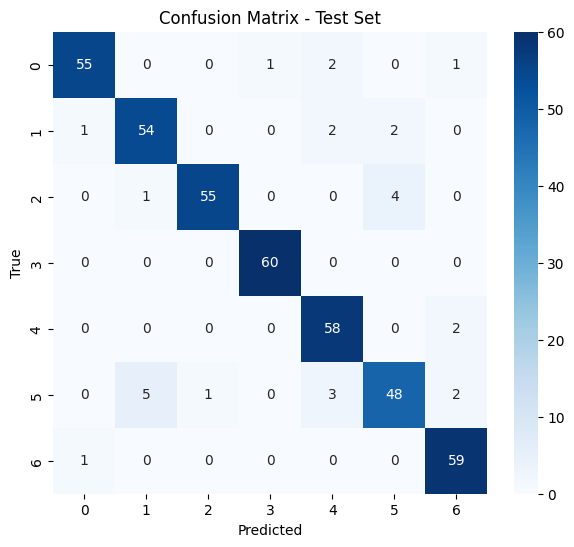

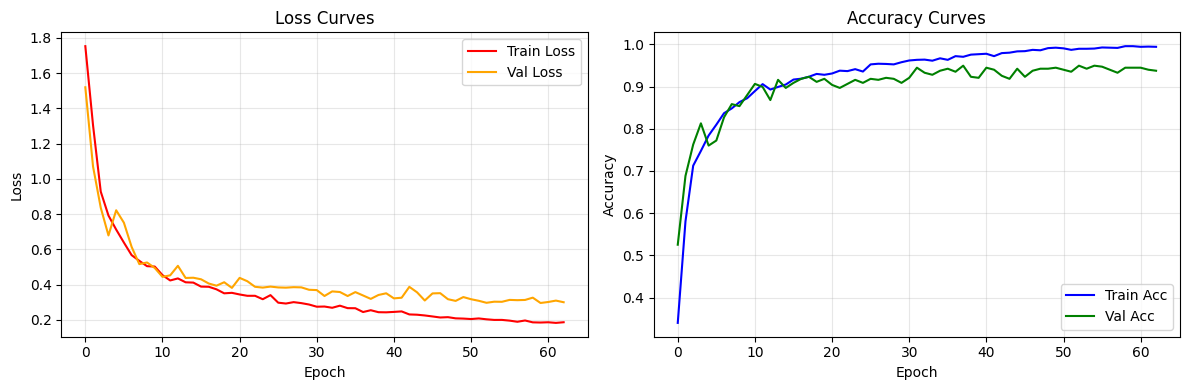


🏁 Training complete
Best Validation Accuracy: 0.9496
Final Test Accuracy: 0.9329
Train graphs: 1945 | Val: 417 | Test: 417


In [ ]:
# ==========================================================
# V7.3.0 - GraphSAGE + EdgeMLP (2 layers) + RWR + Gated Attention Pooling
# - RWR (diffusion après 2e conv, mix résiduel apprenable)
# - AttentivePool: le modèle apprend à pondérer les nœuds pertinents
# - Normalisation train-only, DropEdge, Label Smoothing, courbes & rapports
# ==========================================================

import torch
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing, BatchNorm
from torch_geometric.loader import DataLoader
from torch_geometric.utils import dropout_edge, add_self_loops, to_undirected, degree, scatter as pyg_scatter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Config
# -----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

BATCH_SIZE = 24
HIDDEN = 96
DROPOUT_P = 0.3
WEIGHT_DECAY = 1e-3
BASE_LR = 1e-3
MAX_EPOCHS = 120
PATIENCE_ES = 25
USE_DROPEDGE = True
DROPEDGE_P = 0.10
GRAD_CLIP_NORM = 1.0
WARMUP_EPOCHS = 5
COSINE_TMAX = 80
LABEL_SMOOTH_EPS = 0.02
SAVE_PATH = "/content/drive/MyDrive/best_graphsage_v7_3_0_ATTNP.pt"

# RWR hyperparams
RWR_ALPHA = 0.15
RWR_STEPS = 10

# -----------------------------
# Label smoothing loss
# -----------------------------
class LabelSmoothingCrossEntropy(torch.nn.Module):
    def __init__(self, eps):
        super().__init__()
        self.eps = eps
        self.log_softmax = torch.nn.LogSoftmax(dim=-1)
    def forward(self, preds, targets):
        n_classes = preds.size(-1)
        log_preds = self.log_softmax(preds)
        with torch.no_grad():
            true_dist = torch.zeros_like(log_preds)
            true_dist.fill_(self.eps / (n_classes - 1))
            true_dist.scatter_(1, targets.data.unsqueeze(1), 1 - self.eps)
        return torch.mean(torch.sum(-true_dist * log_preds, dim=-1))

# -----------------------------
# EdgeSAGEConv (v2.1 - BN + Dropout)
# -----------------------------
class EdgeSAGEConv(MessagePassing):
    def __init__(self, in_channels, out_channels, edge_dim, dropout_p=0.3):
        super().__init__(aggr='mean')
        self.lin_node = torch.nn.Linear(in_channels, out_channels, bias=False)

        self.edge_mlp = torch.nn.Sequential(
            torch.nn.Linear(out_channels + edge_dim, out_channels),
            torch.nn.ReLU(),
            torch.nn.BatchNorm1d(out_channels),
            torch.nn.Dropout(p=dropout_p),
            torch.nn.Linear(out_channels, out_channels)
        )

        self.update_lin = torch.nn.Linear(out_channels, out_channels)

    def forward(self, x, edge_index, edge_attr):
        h = self.lin_node(x)
        out = self.propagate(edge_index, x=h, edge_attr=edge_attr)
        return self.update_lin(F.leaky_relu(h + out, negative_slope=0.1))

    def message(self, x_j, edge_attr):
        m = torch.cat([x_j, edge_attr], dim=-1)
        return self.edge_mlp(m)

# -----------------------------
# Random Walk with Restart (RWR) diffusion
# -----------------------------
class RandomWalkWithRestart(torch.nn.Module):
    """
    h_{t+1} = (1 - alpha) * P * h_t + alpha * h0
    avec P = D^{-1} A (self-loops inclus). Batch-safe (graphiques disjoints).
    """
    def __init__(self, alpha=0.15, steps=10, add_loops=True, symmetric_undirected=True):
        super().__init__()
        self.alpha = alpha
        self.steps = steps
        self.add_loops = add_loops
        self.symmetric_undirected = symmetric_undirected

    def forward(self, x, edge_index):
        N = x.size(0)
        device = x.device

        ei = edge_index
        if self.symmetric_undirected:
            ei = to_undirected(ei, num_nodes=N)
        if self.add_loops:
            ei, _ = add_self_loops(ei, num_nodes=N)

        row, col = ei[0], ei[1]
        deg = degree(row, N, dtype=x.dtype).clamp(min=1)
        vals = 1.0 / deg[row]

        P = torch.sparse_coo_tensor(
            torch.stack([row, col]),
            vals.to(device),
            size=(N, N),
            device=device
        ).coalesce()

        h0 = x
        h = x
        one_minus_alpha = 1.0 - self.alpha
        for _ in range(self.steps):
            h = one_minus_alpha * torch.sparse.mm(P, h) + self.alpha * h0
        return h

# -----------------------------
# Attentive Pooling (focus auto)
# -----------------------------
class AttentivePool(torch.nn.Module):
    """
    Apprend un gate g_i ∈ (0,1) par nœud, puis calcule:
      - mean pondérée: sum(g_i x_i) / sum(g_i)
      - max “pondérée” (approx): max(g_i * x_i)
    Renvoie concat([mean_w, max_w]) de taille 2*hidden_dim.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.gate = torch.nn.Sequential(
            torch.nn.Linear(hidden_dim, hidden_dim // 2),
            torch.nn.ReLU(inplace=True),
            torch.nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x, batch):
        # gate ∈ (0,1), shape (N,)
        g = torch.sigmoid(self.gate(x)).squeeze(-1)
        g = g + 1e-6  # stabilité

        # mean pondérée
        sum_x = pyg_scatter(x * g.unsqueeze(-1), batch, dim=0, reduce='sum')
        sum_w = pyg_scatter(g, batch, dim=0, reduce='sum').unsqueeze(-1)
        mean_w = sum_x / sum_w

        # max “pondérée” (approximation): max(g_i * x_i) par graphe
        x_masked = x * g.unsqueeze(-1)
        max_w = pyg_scatter(x_masked, batch, dim=0, reduce='max')

        return torch.cat([mean_w, max_w], dim=-1)

# -----------------------------
# Modèle: 2x EdgeSAGE + RWR + AttentivePool
# -----------------------------
class GraphSAGE_EdgeMLP2L(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, edge_dim, dropout_p=0.4,
                 rwr_alpha=0.15, rwr_steps=10):
        super().__init__()
        self.conv1 = EdgeSAGEConv(in_channels, hidden_channels, edge_dim)
        self.bn1 = BatchNorm(hidden_channels)
        self.conv2 = EdgeSAGEConv(hidden_channels, hidden_channels, edge_dim)
        self.bn2 = BatchNorm(hidden_channels)

        # Diffusion RWR + gate apprenable pour mixer
        self.rwr = RandomWalkWithRestart(alpha=rwr_alpha, steps=rwr_steps)
        self.rwr_gamma = torch.nn.Parameter(torch.tensor(0.0))  # sigmoid(0)=0.5

        # Attentive Pooling
        self.pool = AttentivePool(hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels * 2, num_classes)

        self.dropout = torch.nn.Dropout(dropout_p)
        self.act = lambda x: F.leaky_relu(x, 0.1)

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.act(self.bn1(self.conv1(x, edge_index, edge_attr)))
        x = self.dropout(x)

        # RWR + mix résiduel
        x_rwr = self.rwr(x, edge_index)
        g = torch.sigmoid(self.rwr_gamma)
        x = (1 - g) * x + g * x_rwr

        x = self.act(self.bn2(self.conv2(x, edge_index, edge_attr)))
        x = self.dropout(x)

        # Pooling attentionné (focus auto)
        x_readout = self.pool(x, batch)
        return self.lin(x_readout)

# -----------------------------
# Data preparation
# -----------------------------
assert 'graph_list' in globals(), "⚠️ Le dataset 'graph_list' doit être chargé avant ce script."

edge_dim = graph_list[0].edge_attr.shape[1]
in_channels = graph_list[0].x.shape[1]  # 15 après correction LBP
y_all = np.array([g.y.item() for g in graph_list])
num_classes = int(y_all.max() + 1)
print(f"Node feature dim: {in_channels} | Edge feature dim: {edge_dim} | Classes: {num_classes}")

# Split 70/15/15
train_idx, test_idx = train_test_split(np.arange(len(graph_list)), test_size=0.30, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, stratify=y_all[test_idx], random_state=42)

train_graphs = [graph_list[i] for i in train_idx]
val_graphs   = [graph_list[i] for i in val_idx]
test_graphs  = [graph_list[i] for i in test_idx]

print(f"Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")

# -----------------------------
# Normalisation "train-only"
# -----------------------------
def scale_graphs(graphs, scaler_x, scaler_e):
    for g in graphs:
        g.x = torch.tensor(scaler_x.transform(g.x.numpy()), dtype=torch.float32)
        g.edge_attr = torch.tensor(scaler_e.transform(g.edge_attr.numpy()), dtype=torch.float32)
    return graphs

all_X_train = np.vstack([g.x.numpy() for g in train_graphs])
scaler_x = StandardScaler().fit(all_X_train)
all_E_train = np.vstack([g.edge_attr.numpy() for g in train_graphs])
scaler_e = StandardScaler().fit(all_E_train)

train_graphs = scale_graphs(train_graphs, scaler_x, scaler_e)
val_graphs   = scale_graphs(val_graphs, scaler_x, scaler_e)
test_graphs  = scale_graphs(test_graphs, scaler_x, scaler_e)

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# Training helpers
# -----------------------------
def train_epoch(loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for data in loader:
        data = data.to(DEVICE)
        edge_index, edge_attr = data.edge_index, data.edge_attr

        # DropEdge (optionnel)
        if USE_DROPEDGE:
            edge_index, mask = dropout_edge(edge_index, p=DROPEDGE_P, training=True)
            if mask is not None:
                if mask.dtype == torch.bool:
                    edge_attr = edge_attr[mask]
                else:
                    edge_attr = edge_attr[mask.long()]

        # Bruit léger
        data.x = data.x + 0.01 * torch.randn_like(data.x)
        edge_attr = edge_attr + 0.01 * torch.randn_like(edge_attr)

        optimizer.zero_grad()
        out = model(data.x, edge_index.to(DEVICE), edge_attr.to(DEVICE), data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()

        total_loss += loss.item() * data.num_graphs
        correct += (out.argmax(dim=1) == data.y).sum().item()
        total += data.num_graphs

    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for data in loader:
        data = data.to(DEVICE)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        loss = criterion(out, data.y)
        total_loss += loss.item() * data.num_graphs
        correct += (out.argmax(dim=1) == data.y).sum().item()
        total += data.num_graphs
    return total_loss / total, correct / total

# -----------------------------
# Model / optimizer / scheduler / loss
# -----------------------------
model = GraphSAGE_EdgeMLP2L(
    in_channels, HIDDEN, num_classes, edge_dim, DROPOUT_P,
    rwr_alpha=RWR_ALPHA, rwr_steps=RWR_STEPS
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=COSINE_TMAX, eta_min=1e-6)

if LABEL_SMOOTH_EPS > 0:
    criterion = LabelSmoothingCrossEntropy(eps=LABEL_SMOOTH_EPS)
else:
    criterion = torch.nn.CrossEntropyLoss()

# -----------------------------
# Training loop
# -----------------------------
best_val_acc = 0.0
patience_counter = 0
train_losses, val_losses, train_accs, val_accs, lrs = [], [], [], [], []

for epoch in range(1, MAX_EPOCHS + 1):
    if epoch <= WARMUP_EPOCHS:
        for g in optimizer.param_groups:
            g['lr'] = (epoch / float(max(1, WARMUP_EPOCHS))) * BASE_LR

    tr_loss, tr_acc = train_epoch(train_loader)
    va_loss, va_acc = eval_epoch(val_loader)
    scheduler.step()

    train_losses.append(tr_loss); val_losses.append(va_loss)
    train_accs.append(tr_acc); val_accs.append(va_acc)
    lrs.append(optimizer.param_groups[0]['lr'])

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train Loss: {tr_loss:.4f} | Val Loss: {va_loss:.4f} "
              f"| Train Acc: {tr_acc:.4f} | Val Acc: {va_acc:.4f} | LR: {lrs[-1]:.6f}")

    if va_acc > best_val_acc + 1e-6:
        best_val_acc = va_acc
        patience_counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE_ES:
        print(f"\n⏸️ Early stopping at epoch {epoch} (best val acc {best_val_acc:.4f})")
        break

print(f"\n✅ Best Validation Accuracy: {best_val_acc:.4f}")

# -----------------------------
# Test evaluation
# -----------------------------
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
test_loss, test_acc = eval_epoch(test_loader)
print(f"✅ Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

# -----------------------------
# Confusion matrix & classification report
# -----------------------------
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for data in test_loader:
        data = data.to(DEVICE)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        preds = out.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(data.y.cpu().numpy())

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# -----------------------------
# Plot learning curves
# -----------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss', color='red')
plt.plot(val_losses, label='Val Loss', color='orange')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss Curves'); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc', color='blue')
plt.plot(val_accs, label='Val Acc', color='green')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy Curves'); plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\n🏁 Training complete")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Train graphs: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")

Device: cuda
Node feature dim: 15 | Edge feature dim: 3 | Classes: 7
Train: 1945 | Val: 417 | Test: 417


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 001 | Train Loss: 1.8831 | Val Loss: 1.5735 | Train Acc: 0.2643 | Val Acc: 0.4508 | LR: 0.000200
Epoch 005 | Train Loss: 0.7960 | Val Loss: 0.7368 | Train Acc: 0.7434 | Val Acc: 0.7866 | LR: 0.000997
Epoch 010 | Train Loss: 0.5273 | Val Loss: 0.4950 | Train Acc: 0.8586 | Val Acc: 0.8729 | LR: 0.000968
Epoch 015 | Train Loss: 0.4408 | Val Loss: 0.4460 | Train Acc: 0.8936 | Val Acc: 0.8921 | LR: 0.000921
Epoch 020 | Train Loss: 0.3989 | Val Loss: 0.4274 | Train Acc: 0.9136 | Val Acc: 0.9137 | LR: 0.000859
Epoch 025 | Train Loss: 0.3811 | Val Loss: 0.3837 | Train Acc: 0.9183 | Val Acc: 0.9113 | LR: 0.000783
Epoch 030 | Train Loss: 0.3306 | Val Loss: 0.3821 | Train Acc: 0.9393 | Val Acc: 0.9161 | LR: 0.000696
Epoch 035 | Train Loss: 0.3140 | Val Loss: 0.3297 | Train Acc: 0.9445 | Val Acc: 0.9376 | LR: 0.000602
Epoch 040 | Train Loss: 0.2769 | Val Loss: 0.3611 | Train Acc: 0.9568 | Val Acc: 0.9209 | LR: 0.000504
Epoch 045 | Train Loss: 0.2541 | Val Loss: 0.3706 | Train Acc: 0.9712 | V

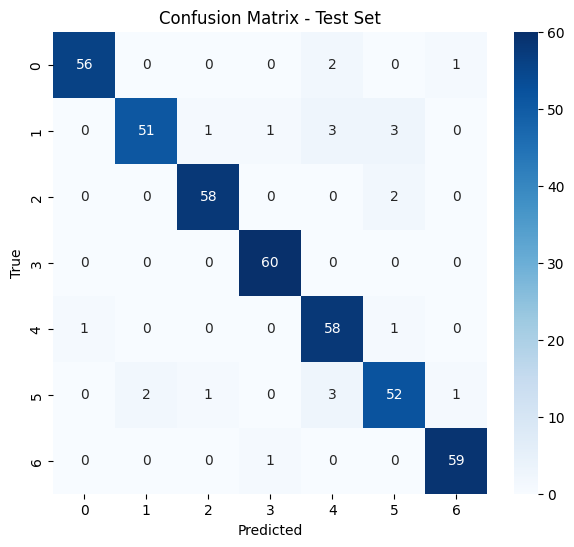

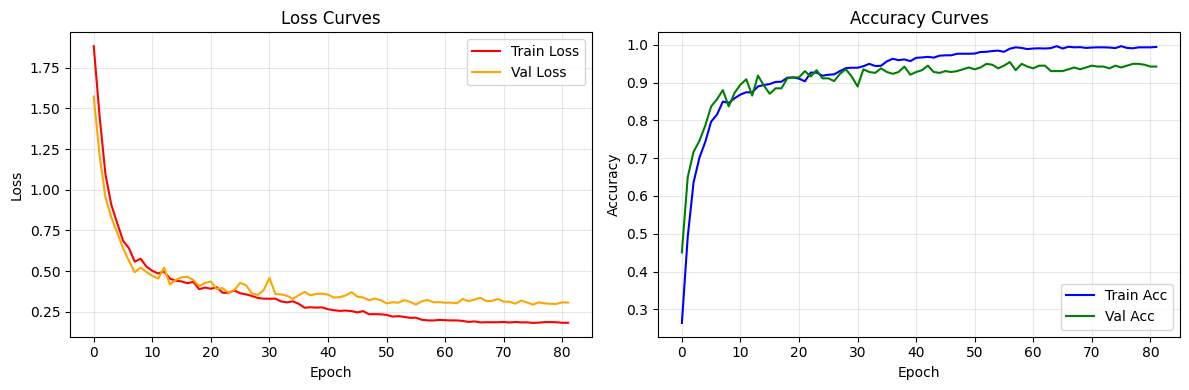


🏁 Training complete
Best Validation Accuracy: 0.9544
Final Test Accuracy: 0.9448
Train graphs: 1945 | Val: 417 | Test: 417


In [ ]:
# ==========================================================
# V7.4.1 - GraphSAGE + EdgeMLP (2 layers) + Weighted RWR + Concat Fusion
# - RWR pondéré par edge_attr (softplus + normalisation par ligne)
# - Fusion x || x_rwr puis petite projection (plus flexible que mix scalaire)
# - Readout = mean + max (baseline performante)
# - Train-only scaling, DropEdge, Label Smoothing, courbes & rapports
# ==========================================================

import torch
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing, global_mean_pool, global_max_pool, BatchNorm
from torch_geometric.loader import DataLoader
from torch_geometric.utils import (
    dropout_edge, add_self_loops, to_undirected
)
from torch_geometric.utils import scatter as pyg_scatter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Config
# -----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

BATCH_SIZE = 24
HIDDEN = 96
DROPOUT_P = 0.3
WEIGHT_DECAY = 1e-3
BASE_LR = 1e-3
MAX_EPOCHS = 120
PATIENCE_ES = 25
USE_DROPEDGE = True
DROPEDGE_P = 0.10
GRAD_CLIP_NORM = 1.0
WARMUP_EPOCHS = 5
COSINE_TMAX = 80
LABEL_SMOOTH_EPS = 0.02
SAVE_PATH = "/content/drive/MyDrive/best_graphsage_v7_4_1_WRWR.pt"

# Weighted RWR hyperparams
RWR_ALPHA = 0.15
RWR_STEPS = 10
EDGE_WEIGHT_COL = 0        # colonne de edge_attr utilisée si USE_EDGE_MLP=False
USE_EDGE_MLP = False       # True: apprend le poids via un MLP sur edge_attr

# -----------------------------
# Label smoothing loss
# -----------------------------
class LabelSmoothingCrossEntropy(torch.nn.Module):
    def __init__(self, eps):
        super().__init__()
        self.eps = eps
        self.log_softmax = torch.nn.LogSoftmax(dim=-1)
    def forward(self, preds, targets):
        n_classes = preds.size(-1)
        log_preds = self.log_softmax(preds)
        with torch.no_grad():
            true_dist = torch.zeros_like(log_preds)
            true_dist.fill_(self.eps / (n_classes - 1))
            true_dist.scatter_(1, targets.data.unsqueeze(1), 1 - self.eps)
        return torch.mean(torch.sum(-true_dist * log_preds, dim=-1))

# -----------------------------
# EdgeSAGEConv (v2.1 - BN + Dropout)
# -----------------------------
class EdgeSAGEConv(MessagePassing):
    def __init__(self, in_channels, out_channels, edge_dim, dropout_p=0.3):
        super().__init__(aggr='mean')
        self.lin_node = torch.nn.Linear(in_channels, out_channels, bias=False)

        self.edge_mlp = torch.nn.Sequential(
            torch.nn.Linear(out_channels + edge_dim, out_channels),
            torch.nn.ReLU(),
            torch.nn.BatchNorm1d(out_channels),
            torch.nn.Dropout(p=dropout_p),
            torch.nn.Linear(out_channels, out_channels)
        )

        self.update_lin = torch.nn.Linear(out_channels, out_channels)

    def forward(self, x, edge_index, edge_attr):
        h = self.lin_node(x)
        out = self.propagate(edge_index, x=h, edge_attr=edge_attr)
        return self.update_lin(F.leaky_relu(h + out, negative_slope=0.1))

    def message(self, x_j, edge_attr):
        m = torch.cat([x_j, edge_attr], dim=-1)
        return self.edge_mlp(m)

# -----------------------------
# Weighted Random Walk with Restart (WRWR)
# -----------------------------
class WeightedRWR(torch.nn.Module):
    """
    h_{t+1} = (1 - alpha) * P_w * h_t + alpha * h0
    P_w: transition row-stochastic avec poids d'arêtes w_ij >= 0
         (issus d'une colonne de edge_attr ou d'un petit MLP), normalisés par ligne.
    """
    def __init__(self, alpha=0.15, steps=10, add_loops=True, symmetric_undirected=True,
                 edge_dim=1, use_edge_mlp=False, edge_weight_col=0):
        super().__init__()
        self.alpha = alpha
        self.steps = steps
        self.add_loops = add_loops
        self.symmetric_undirected = symmetric_undirected
        self.use_edge_mlp = use_edge_mlp
        self.edge_weight_col = edge_weight_col

        if use_edge_mlp:
            self.edge_weight_net = torch.nn.Sequential(
                torch.nn.Linear(edge_dim, max(8, edge_dim)),
                torch.nn.ReLU(inplace=True),
                torch.nn.Linear(max(8, edge_dim), 1)
            )
        else:
            self.edge_weight_net = None

        self.softplus = torch.nn.Softplus()

    def _compute_edge_weights(self, edge_attr):
        if self.use_edge_mlp:
            w_raw = self.edge_weight_net(edge_attr).squeeze(-1)  # (E,)
        else:
            w_raw = edge_attr[:, self.edge_weight_col]           # (E,)
        w = self.softplus(w_raw) + 1e-8
        return w

    def forward(self, x, edge_index, edge_attr, num_nodes=None):
        N = x.size(0) if num_nodes is None else num_nodes
        device = x.device

        ei = edge_index
        ea = edge_attr

        # 1) Symétrisation en conservant la cohérence des edge_attr
        if self.symmetric_undirected:
            if ea is not None:
                ei, ea = to_undirected(ei, num_nodes=N, edge_attr=ea, reduce='mean')
            else:
                ei = to_undirected(ei, num_nodes=N)

        # 2) Self-loops avec edge_attr cohérents
        if self.add_loops:
            if ea is not None:
                fill_value = torch.ones(ea.size(1), device=device, dtype=ea.dtype)
                ei, ea = add_self_loops(ei, edge_attr=ea, fill_value=fill_value, num_nodes=N)
            else:
                ei, _ = add_self_loops(ei, num_nodes=N)

        row, col = ei[0], ei[1]

        # 3) Poids non normalisés
        if ea is None:
            w_raw = torch.ones(row.size(0), device=device)
        else:
            w_raw = self._compute_edge_weights(ea).to(device)

        # 4) Normalisation par ligne → P_w
        row_sum = pyg_scatter(w_raw, row, dim=0, dim_size=N, reduce='sum').clamp(min=1e-8)
        vals = w_raw / row_sum[row]

        P = torch.sparse_coo_tensor(
            torch.stack([row, col]),
            vals,
            size=(N, N),
            device=device
        ).coalesce()

        # 5) Diffusion itérative
        h0 = x
        h = x
        one_minus_alpha = 1.0 - self.alpha
        for _ in range(self.steps):
            h = one_minus_alpha * torch.sparse.mm(P, h) + self.alpha * h0
        return h

# -----------------------------
# Modèle: 2x EdgeSAGE + WRWR + Concat-Fuse + Mean/Max
# -----------------------------
class GraphSAGE_EdgeMLP2L(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, edge_dim, dropout_p=0.4,
                 rwr_alpha=0.15, rwr_steps=10, use_edge_mlp=False, edge_weight_col=0):
        super().__init__()
        self.conv1 = EdgeSAGEConv(in_channels, hidden_channels, edge_dim)
        self.bn1 = BatchNorm(hidden_channels)
        self.conv2 = EdgeSAGEConv(hidden_channels, hidden_channels, edge_dim)
        self.bn2 = BatchNorm(hidden_channels)

        # Weighted RWR
        self.wrwr = WeightedRWR(
            alpha=rwr_alpha, steps=rwr_steps, edge_dim=edge_dim,
            use_edge_mlp=use_edge_mlp, edge_weight_col=edge_weight_col
        )

        # Concat -> petite projection vers hidden_channels
        self.fuse = torch.nn.Sequential(
            torch.nn.Linear(hidden_channels * 2, hidden_channels),
            torch.nn.ReLU(inplace=True),
            torch.nn.BatchNorm1d(hidden_channels),
            torch.nn.Dropout(p=dropout_p)
        )

        # Head (mean + max)
        self.lin = torch.nn.Linear(hidden_channels * 2, num_classes)
        self.dropout = torch.nn.Dropout(dropout_p)
        self.act = lambda x: F.leaky_relu(x, 0.1)

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.act(self.bn1(self.conv1(x, edge_index, edge_attr)))
        x = self.dropout(x)

        # Diffusion pondérée par arêtes
        x_rwr = self.wrwr(x, edge_index, edge_attr, num_nodes=x.size(0))

        # Concat -> projection
        x = torch.cat([x, x_rwr], dim=-1)
        x = self.fuse(x)

        x = self.act(self.bn2(self.conv2(x, edge_index, edge_attr)))
        x = self.dropout(x)

        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        return self.lin(torch.cat([x_mean, x_max], dim=1))

# -----------------------------
# Data preparation
# -----------------------------
assert 'graph_list' in globals(), "⚠️ Le dataset 'graph_list' doit être chargé avant ce script."

edge_dim = graph_list[0].edge_attr.shape[1]
in_channels = graph_list[0].x.shape[1]  # 15
y_all = np.array([g.y.item() for g in graph_list])
num_classes = int(y_all.max() + 1)
print(f"Node feature dim: {in_channels} | Edge feature dim: {edge_dim} | Classes: {num_classes}")

# Split 70/15/15
train_idx, test_idx = train_test_split(np.arange(len(graph_list)), test_size=0.30, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, stratify=y_all[test_idx], random_state=42)

train_graphs = [graph_list[i] for i in train_idx]
val_graphs   = [graph_list[i] for i in val_idx]
test_graphs  = [graph_list[i] for i in test_idx]

print(f"Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")

# -----------------------------
# Normalisation "train-only"
# -----------------------------
def scale_graphs(graphs, scaler_x, scaler_e):
    for g in graphs:
        g.x = torch.tensor(scaler_x.transform(g.x.numpy()), dtype=torch.float32)
        g.edge_attr = torch.tensor(scaler_e.transform(g.edge_attr.numpy()), dtype=torch.float32)
    return graphs

all_X_train = np.vstack([g.x.numpy() for g in train_graphs])
scaler_x = StandardScaler().fit(all_X_train)
all_E_train = np.vstack([g.edge_attr.numpy() for g in train_graphs])
scaler_e = StandardScaler().fit(all_E_train)

train_graphs = scale_graphs(train_graphs, scaler_x, scaler_e)
val_graphs   = scale_graphs(val_graphs, scaler_x, scaler_e)
test_graphs  = scale_graphs(test_graphs, scaler_x, scaler_e)

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# Training helpers
# -----------------------------
def train_epoch(loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for data in loader:
        data = data.to(DEVICE)
        edge_index, edge_attr = data.edge_index, data.edge_attr

        # DropEdge (optionnel)
        if USE_DROPEDGE:
            edge_index, mask = dropout_edge(edge_index, p=DROPEDGE_P, training=True)
            if mask is not None:
                if mask.dtype == torch.bool:
                    edge_attr = edge_attr[mask]
                else:
                    edge_attr = edge_attr[mask.long()]

        # Bruit léger
        data.x = data.x + 0.01 * torch.randn_like(data.x)
        edge_attr = edge_attr + 0.01 * torch.randn_like(edge_attr)

        optimizer.zero_grad()
        out = model(data.x, edge_index.to(DEVICE), edge_attr.to(DEVICE), data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()

        total_loss += loss.item() * data.num_graphs
        correct += (out.argmax(dim=1) == data.y).sum().item()
        total += data.num_graphs

    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for data in loader:
        data = data.to(DEVICE)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        loss = criterion(out, data.y)
        total_loss += loss.item() * data.num_graphs
        correct += (out.argmax(dim=1) == data.y).sum().item()
        total += data.num_graphs
    return total_loss / total, correct / total

# -----------------------------
# Model / optimizer / scheduler / loss
# -----------------------------
model = GraphSAGE_EdgeMLP2L(
    in_channels, HIDDEN, num_classes, edge_dim, DROPOUT_P,
    rwr_alpha=RWR_ALPHA, rwr_steps=RWR_STEPS,
    use_edge_mlp=USE_EDGE_MLP, edge_weight_col=EDGE_WEIGHT_COL
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=COSINE_TMAX, eta_min=1e-6)

if LABEL_SMOOTH_EPS > 0:
    criterion = LabelSmoothingCrossEntropy(eps=LABEL_SMOOTH_EPS)
else:
    criterion = torch.nn.CrossEntropyLoss()

# -----------------------------
# Training loop
# -----------------------------
best_val_acc = 0.0
patience_counter = 0
train_losses, val_losses, train_accs, val_accs, lrs = [], [], [], [], []

for epoch in range(1, MAX_EPOCHS + 1):
    if epoch <= WARMUP_EPOCHS:
        for g in optimizer.param_groups:
            g['lr'] = (epoch / float(max(1, WARMUP_EPOCHS))) * BASE_LR

    tr_loss, tr_acc = train_epoch(train_loader)
    va_loss, va_acc = eval_epoch(val_loader)
    scheduler.step()

    train_losses.append(tr_loss); val_losses.append(va_loss)
    train_accs.append(tr_acc); val_accs.append(va_acc)
    lrs.append(optimizer.param_groups[0]['lr'])

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train Loss: {tr_loss:.4f} | Val Loss: {va_loss:.4f} "
              f"| Train Acc: {tr_acc:.4f} | Val Acc: {va_acc:.4f} | LR: {lrs[-1]:.6f}")

    if va_acc > best_val_acc + 1e-6:
        best_val_acc = va_acc
        patience_counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE_ES:
        print(f"\n⏸️ Early stopping at epoch {epoch} (best val acc {best_val_acc:.4f})")
        break

print(f"\n✅ Best Validation Accuracy: {best_val_acc:.4f}")

# -----------------------------
# Test evaluation
# -----------------------------
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
test_loss, test_acc = eval_epoch(test_loader)
print(f"✅ Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

# -----------------------------
# Confusion matrix & classification report
# -----------------------------
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for data in test_loader:
        data = data.to(DEVICE)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        preds = out.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(data.y.cpu().numpy())

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# -----------------------------
# Plot learning curves
# -----------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss', color='red')
plt.plot(val_losses, label='Val Loss', color='orange')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss Curves'); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc', color='blue')
plt.plot(val_accs, label='Val Acc', color='green')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy Curves'); plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\n🏁 Training complete")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Train graphs: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")

Device: cuda
Node feature dim: 15 | Edge feature dim: 3 | Classes: 7
Train: 1945 | Val: 417 | Test: 417
Class weights: [0.99948615 0.99948615 0.99948615 0.99948615 0.99948615 0.99948615
 1.0030944 ]


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 001 | Train Loss: 1.8670 | Val Loss: 1.6251 | Train Acc: 0.2653 | Val Acc: 0.4173 | LR: 0.000200
Epoch 005 | Train Loss: 0.7210 | Val Loss: 0.7603 | Train Acc: 0.7321 | Val Acc: 0.7698 | LR: 0.000997
Epoch 010 | Train Loss: 0.4451 | Val Loss: 0.4325 | Train Acc: 0.8452 | Val Acc: 0.8657 | LR: 0.000968
Epoch 015 | Train Loss: 0.3908 | Val Loss: 0.3059 | Train Acc: 0.8684 | Val Acc: 0.8945 | LR: 0.000921
Epoch 020 | Train Loss: 0.3046 | Val Loss: 0.4124 | Train Acc: 0.8900 | Val Acc: 0.8465 | LR: 0.000859
Epoch 025 | Train Loss: 0.2821 | Val Loss: 0.2278 | Train Acc: 0.8941 | Val Acc: 0.9281 | LR: 0.000783
Epoch 030 | Train Loss: 0.2179 | Val Loss: 0.3154 | Train Acc: 0.9260 | Val Acc: 0.8945 | LR: 0.000696
Epoch 035 | Train Loss: 0.1659 | Val Loss: 0.2590 | Train Acc: 0.9352 | Val Acc: 0.9185 | LR: 0.000602
Epoch 040 | Train Loss: 0.1564 | Val Loss: 0.2793 | Train Acc: 0.9455 | Val Acc: 0.9113 | LR: 0.000504
Epoch 045 | Train Loss: 0.1207 | Val Loss: 0.2277 | Train Acc: 0.9614 | V

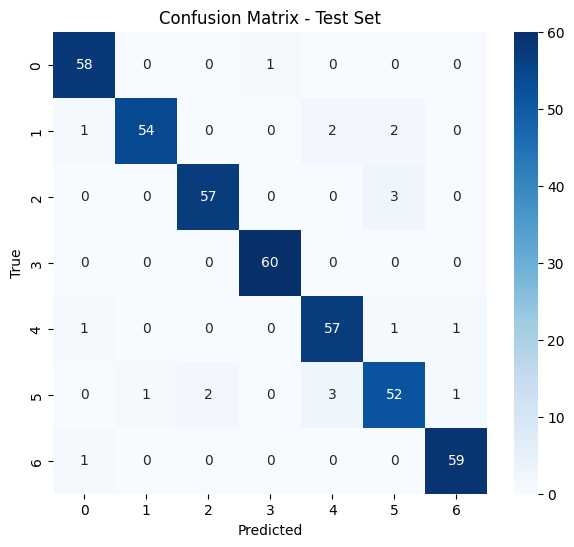

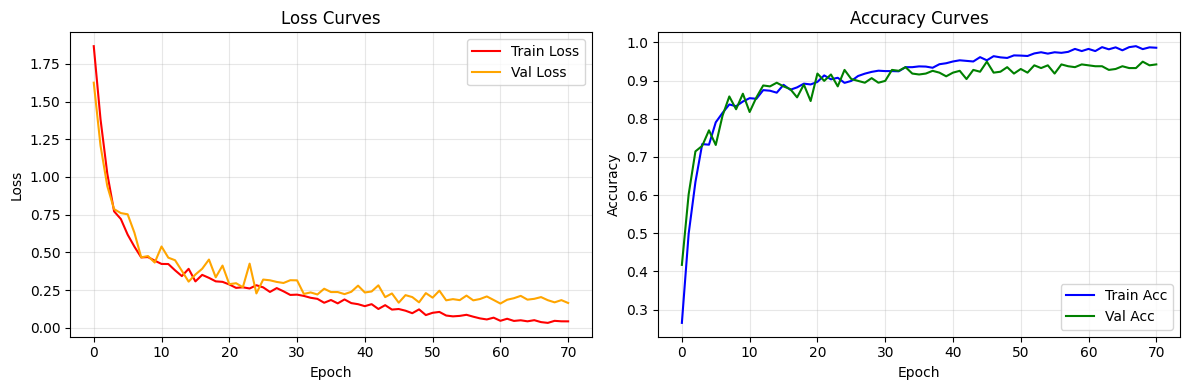


🏁 Training complete
Best Validation Accuracy: 0.9496
Final Test Accuracy: 0.9520
Train graphs: 1945 | Val: 417 | Test: 417


In [ ]:
# ==========================================================
# V7.5.0 - GraphSAGE + EdgeMLP (2 layers) + Weighted RWR (edge MLP)
#        + Concat Fusion + TopKPooling + Class-Weighted CE
# - Poids d’arêtes appris via MLP (WRWR)
# - Concat [x, x_wrwr] -> petite projection
# - TopKPooling pour couper les nœuds "acier propre"
# - CrossEntropy pondérée (mieux pour recall des classes faibles)
# - Train-only scaling, DropEdge, courbes & rapports
# ==========================================================

import torch
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing, BatchNorm, TopKPooling
from torch_geometric.nn import global_mean_pool, global_max_pool
from torch_geometric.loader import DataLoader
from torch_geometric.utils import (
    dropout_edge, add_self_loops, to_undirected
)
from torch_geometric.utils import scatter as pyg_scatter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Config
# -----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

BATCH_SIZE = 24
HIDDEN = 128            # ↑ capacité
DROPOUT_P = 0.4         # un peu plus de régularisation
WEIGHT_DECAY = 1e-3
BASE_LR = 1e-3
MAX_EPOCHS = 120
PATIENCE_ES = 25
USE_DROPEDGE = True
DROPEDGE_P = 0.10
GRAD_CLIP_NORM = 1.0
WARMUP_EPOCHS = 5
COSINE_TMAX = 80
SAVE_PATH = "/content/drive/MyDrive/best_graphsage_v7_5_0_WRWR_TopK_ClassW.pt"

# Weighted RWR (diffusion)
RWR_ALPHA = 0.20
RWR_STEPS = 8
USE_EDGE_MLP = True     # on apprend le poids d’arête à partir de edge_attr
EDGE_WEIGHT_COL = 0     # ignoré si USE_EDGE_MLP=True

# TopK Pooling
TOPK_RATIO = 0.5        # essaie 0.3–0.6 selon la taille des graphes

# -----------------------------
# EdgeSAGEConv (v2.1 - BN + Dropout)
# -----------------------------
class EdgeSAGEConv(MessagePassing):
    def __init__(self, in_channels, out_channels, edge_dim, dropout_p=0.3):
        super().__init__(aggr='mean')
        self.lin_node = torch.nn.Linear(in_channels, out_channels, bias=False)
        self.edge_mlp = torch.nn.Sequential(
            torch.nn.Linear(out_channels + edge_dim, out_channels),
            torch.nn.ReLU(),
            torch.nn.BatchNorm1d(out_channels),
            torch.nn.Dropout(p=dropout_p),
            torch.nn.Linear(out_channels, out_channels)
        )
        self.update_lin = torch.nn.Linear(out_channels, out_channels)

    def forward(self, x, edge_index, edge_attr):
        h = self.lin_node(x)
        out = self.propagate(edge_index, x=h, edge_attr=edge_attr)
        return self.update_lin(F.leaky_relu(h + out, negative_slope=0.1))

    def message(self, x_j, edge_attr):
        m = torch.cat([x_j, edge_attr], dim=-1)
        return self.edge_mlp(m)

# -----------------------------
# Weighted Random Walk with Restart (WRWR)
# -----------------------------
class WeightedRWR(torch.nn.Module):
    """
    h_{t+1} = (1 - alpha) * P_w * h_t + alpha * h0
    P_w: transition row-stochastic avec poids d'arêtes w_ij >= 0
         (issus d'une colonne de edge_attr ou d'un petit MLP), normalisés par ligne.
    """
    def __init__(self, alpha=0.15, steps=10, add_loops=True, symmetric_undirected=True,
                 edge_dim=1, use_edge_mlp=False, edge_weight_col=0):
        super().__init__()
        self.alpha = alpha
        self.steps = steps
        self.add_loops = add_loops
        self.symmetric_undirected = symmetric_undirected
        self.use_edge_mlp = use_edge_mlp
        self.edge_weight_col = edge_weight_col

        if use_edge_mlp:
            self.edge_weight_net = torch.nn.Sequential(
                torch.nn.Linear(edge_dim, max(8, edge_dim)),
                torch.nn.ReLU(inplace=True),
                torch.nn.Linear(max(8, edge_dim), 1)
            )
        else:
            self.edge_weight_net = None

        self.softplus = torch.nn.Softplus()

    def _compute_edge_weights(self, edge_attr):
        if self.use_edge_mlp:
            w_raw = self.edge_weight_net(edge_attr).squeeze(-1)  # (E,)
        else:
            w_raw = edge_attr[:, self.edge_weight_col]           # (E,)
        w = self.softplus(w_raw) + 1e-8
        return w

    def forward(self, x, edge_index, edge_attr, num_nodes=None):
        N = x.size(0) if num_nodes is None else num_nodes
        device = x.device

        ei = edge_index
        ea = edge_attr

        # 1) Symétrisation en conservant la cohérence des edge_attr
        if self.symmetric_undirected:
            if ea is not None:
                ei, ea = to_undirected(ei, num_nodes=N, edge_attr=ea, reduce='mean')
            else:
                ei = to_undirected(ei, num_nodes=N)

        # 2) Self-loops avec edge_attr cohérents
        if self.add_loops:
            if ea is not None:
                fill_value = torch.ones(ea.size(1), device=device, dtype=ea.dtype)
                ei, ea = add_self_loops(ei, edge_attr=ea, fill_value=fill_value, num_nodes=N)
            else:
                ei, _ = add_self_loops(ei, num_nodes=N)

        row, col = ei[0], ei[1]

        # 3) Poids non normalisés
        if ea is None:
            w_raw = torch.ones(row.size(0), device=device)
        else:
            w_raw = self._compute_edge_weights(ea).to(device)

        # 4) Normalisation par ligne → P_w
        row_sum = pyg_scatter(w_raw, row, dim=0, dim_size=N, reduce='sum').clamp(min=1e-8)
        vals = w_raw / row_sum[row]

        P = torch.sparse_coo_tensor(
            torch.stack([row, col]),
            vals,
            size=(N, N),
            device=device
        ).coalesce()

        # 5) Diffusion itérative
        h0 = x
        h = x
        one_minus_alpha = 1.0 - self.alpha
        for _ in range(self.steps):
            h = one_minus_alpha * torch.sparse.mm(P, h) + self.alpha * h0
        return h

# -----------------------------
# Modèle: 2x EdgeSAGE + WRWR + Concat-Fuse + TopK + Mean/Max
# -----------------------------
class GraphSAGE_EdgeMLP2L(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, edge_dim, dropout_p=0.4,
                 rwr_alpha=0.15, rwr_steps=10, use_edge_mlp=False, edge_weight_col=0,
                 topk_ratio=0.5):
        super().__init__()
        self.conv1 = EdgeSAGEConv(in_channels, hidden_channels, edge_dim)
        self.bn1 = BatchNorm(hidden_channels)

        self.conv2 = EdgeSAGEConv(hidden_channels, hidden_channels, edge_dim)
        self.bn2 = BatchNorm(hidden_channels)

        # Weighted RWR
        self.wrwr = WeightedRWR(
            alpha=rwr_alpha, steps=rwr_steps, edge_dim=edge_dim,
            use_edge_mlp=use_edge_mlp, edge_weight_col=edge_weight_col
        )

        # Concat -> petite projection vers hidden_channels
        self.fuse = torch.nn.Sequential(
            torch.nn.Linear(hidden_channels * 2, hidden_channels),
            torch.nn.ReLU(inplace=True),
            torch.nn.BatchNorm1d(hidden_channels),
            torch.nn.Dropout(p=dropout_p)
        )

        # Top-K pooling (réduit les nœuds "acier propre")
        self.topk = TopKPooling(hidden_channels, ratio=topk_ratio)

        # Head (mean + max)
        self.lin = torch.nn.Linear(hidden_channels * 2, num_classes)
        self.dropout = torch.nn.Dropout(dropout_p)
        self.act = lambda x: F.leaky_relu(x, 0.1)

    def forward(self, x, edge_index, edge_attr, batch):
        # 1) Conv1
        x = self.act(self.bn1(self.conv1(x, edge_index, edge_attr)))
        x = self.dropout(x)

        # 2) WRWR diffusion + concat + projection
        x_rwr = self.wrwr(x, edge_index, edge_attr, num_nodes=x.size(0))
        x = torch.cat([x, x_rwr], dim=-1)
        x = self.fuse(x)

        # 3) Conv2
        x = self.act(self.bn2(self.conv2(x, edge_index, edge_attr)))
        x = self.dropout(x)

        # 4) Top-K pooling (réduit le bruit spatial)
        x, edge_index, edge_attr, batch, _, _ = self.topk(x, edge_index, edge_attr=edge_attr, batch=batch)

        # 5) Readout mean + max
        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        return self.lin(torch.cat([x_mean, x_max], dim=1))

# -----------------------------
# Data preparation
# -----------------------------
assert 'graph_list' in globals(), "⚠️ Le dataset 'graph_list' doit être chargé avant ce script."

edge_dim = graph_list[0].edge_attr.shape[1]
in_channels = graph_list[0].x.shape[1]  # 15
y_all = np.array([g.y.item() for g in graph_list])
num_classes = int(y_all.max() + 1)
print(f"Node feature dim: {in_channels} | Edge feature dim: {edge_dim} | Classes: {num_classes}")

# Split 70/15/15
train_idx, test_idx = train_test_split(np.arange(len(graph_list)), test_size=0.30, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, stratify=y_all[test_idx], random_state=42)

train_graphs = [graph_list[i] for i in train_idx]
val_graphs   = [graph_list[i] for i in val_idx]
test_graphs  = [graph_list[i] for i in test_idx]

print(f"Train: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")

# -----------------------------
# Normalisation "train-only"
# -----------------------------
def scale_graphs(graphs, scaler_x, scaler_e):
    for g in graphs:
        g.x = torch.tensor(scaler_x.transform(g.x.numpy()), dtype=torch.float32)
        g.edge_attr = torch.tensor(scaler_e.transform(g.edge_attr.numpy()), dtype=torch.float32)
    return graphs

all_X_train = np.vstack([g.x.numpy() for g in train_graphs])
scaler_x = StandardScaler().fit(all_X_train)
all_E_train = np.vstack([g.edge_attr.numpy() for g in train_graphs])
scaler_e = StandardScaler().fit(all_E_train)

train_graphs = scale_graphs(train_graphs, scaler_x, scaler_e)
val_graphs   = scale_graphs(val_graphs, scaler_x, scaler_e)
test_graphs  = scale_graphs(test_graphs, scaler_x, scaler_e)

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# Class weights (pour CE)
# -----------------------------
y_train = np.array([g.y.item() for g in train_graphs])
counts = np.bincount(y_train, minlength=num_classes).astype(np.float32)
class_weights = (len(y_train) / (num_classes * counts))
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("Class weights:", class_weights.cpu().numpy())

# -----------------------------
# Model / optimizer / scheduler / loss
# -----------------------------
model = GraphSAGE_EdgeMLP2L(
    in_channels, HIDDEN, num_classes, edge_dim, DROPOUT_P,
    rwr_alpha=RWR_ALPHA, rwr_steps=RWR_STEPS,
    use_edge_mlp=USE_EDGE_MLP, edge_weight_col=EDGE_WEIGHT_COL,
    topk_ratio=TOPK_RATIO
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=COSINE_TMAX, eta_min=1e-6)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

# -----------------------------
# Training helpers
# -----------------------------
def train_epoch(loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for data in loader:
        data = data.to(DEVICE)
        edge_index, edge_attr = data.edge_index, data.edge_attr

        # DropEdge (optionnel)
        if USE_DROPEDGE:
            edge_index, mask = dropout_edge(edge_index, p=DROPEDGE_P, training=True)
            if mask is not None:
                if mask.dtype == torch.bool:
                    edge_attr = edge_attr[mask]
                else:
                    edge_attr = edge_attr[mask.long()]

        # Bruit léger
        data.x = data.x + 0.01 * torch.randn_like(data.x)
        edge_attr = edge_attr + 0.01 * torch.randn_like(edge_attr)

        optimizer.zero_grad()
        out = model(data.x, edge_index.to(DEVICE), edge_attr.to(DEVICE), data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()

        total_loss += loss.item() * data.num_graphs
        correct += (out.argmax(dim=1) == data.y).sum().item()
        total += data.num_graphs

    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for data in loader:
        data = data.to(DEVICE)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        loss = criterion(out, data.y)
        total_loss += loss.item() * data.num_graphs
        correct += (out.argmax(dim=1) == data.y).sum().item()
        total += data.num_graphs
    return total_loss / total, correct / total

# -----------------------------
# Training loop
# -----------------------------
best_val_acc = 0.0
patience_counter = 0
train_losses, val_losses, train_accs, val_accs, lrs = [], [], [], [], []

for epoch in range(1, MAX_EPOCHS + 1):
    if epoch <= WARMUP_EPOCHS:
        for g in optimizer.param_groups:
            g['lr'] = (epoch / float(max(1, WARMUP_EPOCHS))) * BASE_LR

    tr_loss, tr_acc = train_epoch(train_loader)
    va_loss, va_acc = eval_epoch(val_loader)
    scheduler.step()

    train_losses.append(tr_loss); val_losses.append(va_loss)
    train_accs.append(tr_acc); val_accs.append(va_acc)
    lrs.append(optimizer.param_groups[0]['lr'])

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train Loss: {tr_loss:.4f} | Val Loss: {va_loss:.4f} "
              f"| Train Acc: {tr_acc:.4f} | Val Acc: {va_acc:.4f} | LR: {lrs[-1]:.6f}")

    if va_acc > best_val_acc + 1e-6:
        best_val_acc = va_acc
        patience_counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE_ES:
        print(f"\n⏸️ Early stopping at epoch {epoch} (best val acc {best_val_acc:.4f})")
        break

print(f"\n✅ Best Validation Accuracy: {best_val_acc:.4f}")

# -----------------------------
# Test evaluation
# -----------------------------
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
test_loss, test_acc = eval_epoch(test_loader)
print(f"✅ Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

# -----------------------------
# Confusion matrix & classification report
# -----------------------------
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for data in test_loader:
        data = data.to(DEVICE)
        out = model(data.x, data.edge_index, data.edge_attr, data.batch)
        preds = out.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(data.y.cpu().numpy())

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# -----------------------------
# Plot learning curves
# -----------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss', color='red')
plt.plot(val_losses, label='Val Loss', color='orange')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss Curves'); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc', color='blue')
plt.plot(val_accs, label='Val Acc', color='green')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy Curves'); plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\n🏁 Training complete")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Train graphs: {len(train_graphs)} | Val: {len(val_graphs)} | Test: {len(test_graphs)}")
